In [1]:
# Minimal imports and reproducibility
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

# metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize
from scipy.stats import pearsonr

# AMP (mixed precision)
from torch.cuda.amp import GradScaler, autocast

# Repro
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
# CHANGE THIS PATH to your dataset root (contains 'images' and 'annotations' folders)
DATA_DIR = r"C:\Users\Ayaan\Desktop\dl\Dataset"  # e.g., "/content/Dataset" or "C:\\Users\\you\\Dataset"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
ANNOT_DIR = os.path.join(DATA_DIR, "annotations")

# Training hyperparams
NUM_CLASSES = 8
BATCH_SIZE = 32              # reduce to 16 if OOM
NUM_EPOCHS = 50              # adjust per your time budget
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0              # 0 is safest on Windows / avoids 0% progress hangs
PIN_MEMORY = torch.cuda.is_available()
LOSS_REG_WEIGHT = 0.5        # weight for valence/arousal regression loss

print("Images dir:", IMAGES_DIR)
print("Annots dir:", ANNOT_DIR)

Images dir: C:\Users\Ayaan\Desktop\dl\Dataset\images
Annots dir: C:\Users\Ayaan\Desktop\dl\Dataset\annotations


In [3]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def sign_agreement(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))

def concordance_ccc(y_true, y_pred):
    x = np.asarray(y_true); y = np.asarray(y_pred)
    if x.size == 0:
        return 0.0
    x_mean, y_mean = x.mean(), y.mean()
    cov = np.mean((x - x_mean) * (y - y_mean))
    var_x = np.mean((x - x_mean) ** 2)
    var_y = np.mean((y - y_mean) ** 2)
    denom = var_x + var_y + (x_mean - y_mean) ** 2
    if denom == 0:
        return 1.0
    return float(2 * cov / denom)

In [4]:
class AffectDataset(Dataset):
    def __init__(self, image_paths, annotations_dir, transform=None):
        self.image_paths = image_paths
        self.annotations_dir = annotations_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def _load_annotation(self, base_idx, suffix):
        f = os.path.join(self.annotations_dir, f"{base_idx}_{suffix}.npy")
        if not os.path.exists(f):
            return None
        return np.load(f, allow_pickle=True)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        base = Path(img_path).stem

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        exp = self._load_annotation(base, "exp")
        val = self._load_annotation(base, "val")
        aro = self._load_annotation(base, "aro")

        def to_scalar(x, default=0.0):
            if x is None:
                return default
            arr = np.array(x)
            return float(arr.item()) if arr.shape == () else float(arr[0])

        # expression default -1, but CrossEntropy requires 0..NUM_CLASSES-1; ensure valid labels exist in split
        if exp is None:
            exp_label = 0
        else:
            arr = np.array(exp)
            exp_label = int(arr.item()) if arr.shape == () else int(arr[0])

        return {
            "image": image,
            "exp": torch.tensor(exp_label, dtype=torch.long),
            "valence": torch.tensor(to_scalar(val), dtype=torch.float32),
            "arousal": torch.tensor(to_scalar(aro), dtype=torch.float32),
        }

In [5]:
# Gather images that have all needed annotations
all_images = sorted([str(p) for p in Path(IMAGES_DIR).glob("*.jpg")])
valid_images, labels = [], []

for p in all_images:
    base = Path(p).stem
    exp_f = os.path.join(ANNOT_DIR, f"{base}_exp.npy")
    val_f = os.path.join(ANNOT_DIR, f"{base}_val.npy")
    aro_f = os.path.join(ANNOT_DIR, f"{base}_aro.npy")
    if os.path.exists(exp_f) and os.path.exists(val_f) and os.path.exists(aro_f):
        valid_images.append(p)
        arr = np.array(np.load(exp_f, allow_pickle=True))
        labels.append(int(arr.item()) if arr.shape == () else int(arr[0]))

print("Total images found:", len(all_images))
print("Images with required annotations:", len(valid_images))

train_paths, val_paths = train_test_split(
    valid_images,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)
print("Train:", len(train_paths), "Val:", len(val_paths))

Total images found: 3999
Images with required annotations: 3999
Train: 3199 Val: 800


In [6]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

train_ds = AffectDataset(train_paths, ANNOT_DIR, transform=train_transform)
val_ds   = AffectDataset(val_paths,   ANNOT_DIR, transform=val_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))

Train batches: 100 Val batches: 25


In [7]:
class Identity(nn.Module):
    def forward(self, x):
        return x

class MultiTaskModel(nn.Module):
    def __init__(self, backbone_name="resnet50", pretrained=True, dropout_p=0.4):
        super().__init__()
        self.backbone_name = backbone_name

        if backbone_name == "resnet50":
            self.backbone = models.resnet50(weights="IMAGENET1K_V1" if pretrained else None)
            dim = self.backbone.fc.in_features
            self.backbone.fc = Identity()

        elif backbone_name == "efficientnet_b3":
            # Use EfficientNet-B3 per instructions
            self.backbone = models.efficientnet_b3(weights="IMAGENET1K_V1" if pretrained else None)
            dim = self.backbone.classifier[1].in_features
            # Replace classifier to expose features; we'll handle pooling manually
            self.backbone.classifier = Identity()

        elif backbone_name == "vgg16":
            self.backbone = models.vgg16(weights="IMAGENET1K_V1" if pretrained else None)
            dim = self.backbone.classifier[6].in_features  # 4096
            self.backbone.classifier[6] = Identity()

        elif backbone_name == "mobilenet_v2":
            self.backbone = models.mobilenet_v2(weights="IMAGENET1K_V1" if pretrained else None)
            dim = self.backbone.classifier[1].in_features
            self.backbone.classifier = Identity()

        else:
            raise ValueError(f"Unsupported backbone: {backbone_name}")

        self.feature_dim = dim

        # classification head (8 classes)
        self.cls_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, NUM_CLASSES),
        )

        # regression head (valence + arousal)
        self.reg_head = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        if self.backbone_name.startswith("efficientnet_"):
            # EfficientNet feature path: features -> GAP -> flatten
            feats = self.backbone.features(x)
            feats = nn.functional.adaptive_avg_pool2d(feats, 1).reshape(x.shape[0], -1)
        else:
            feats = self.backbone(x)
            feats = feats.view(feats.size(0), -1)

        cls_logits = self.cls_head(feats)
        reg_out = self.reg_head(feats)
        return cls_logits, reg_out

In [8]:
ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

def train_one_epoch(model, loader, optimizer, scaler, epoch, device):
    model.train()
    total_loss, iters = 0.0, 0
    for batch in tqdm(loader, desc=f"Train E{epoch}"):
        imgs = batch["image"].to(device, non_blocking=True)
        labels = batch["exp"].to(device, non_blocking=True)
        reg_target = torch.stack([batch["valence"], batch["arousal"]], dim=1).to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits, reg_out = model(imgs)
            loss_cls = ce_loss(logits, labels)
            loss_reg = mse_loss(reg_out, reg_target)
            loss = loss_cls + LOSS_REG_WEIGHT * loss_reg
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        iters += 1
    return total_loss / max(iters, 1)

def validate(model, loader, device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    all_val, all_aro, pred_val, pred_aro = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validate"):
            imgs = batch["image"].to(device, non_blocking=True)
            labels = batch["exp"].cpu().numpy()
            valence = batch["valence"].cpu().numpy()
            arousal = batch["arousal"].cpu().numpy()

            logits, reg_out = model(imgs)
            probs = nn.functional.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            reg_np = reg_out.cpu().numpy()

            all_preds.extend(preds.tolist())
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.tolist())
            all_val.extend(valence.tolist()); all_aro.extend(arousal.tolist())
            pred_val.extend(reg_np[:, 0].tolist()); pred_aro.extend(reg_np[:, 1].tolist())

    metrics = {
        "acc": accuracy_score(all_labels, all_preds),
        "f1_macro": f1_score(all_labels, all_preds, average="macro"),
        "kappa": cohen_kappa_score(all_labels, all_preds),
        "auc_ovr": np.nan,
        "val_rmse": rmse(all_val, pred_val),
        "aro_rmse": rmse(all_aro, pred_aro),
        "val_corr": pearsonr(np.array(all_val), np.array(pred_val))[0] if len(all_val) > 1 else 0.0,
        "aro_corr": pearsonr(np.array(all_aro), np.array(pred_aro))[0] if len(all_aro) > 1 else 0.0,
        "val_sagr": sign_agreement(all_val, pred_val),
        "aro_sagr": sign_agreement(all_aro, pred_aro),
        "val_ccc": concordance_ccc(all_val, pred_val),
        "aro_ccc": concordance_ccc(all_aro, pred_aro),
    }
    # AUC-OVR may fail if a class is missing in predictions; guard it
    try:
        y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
        metrics["auc_ovr"] = roc_auc_score(y_bin, np.array(all_probs), average="macro", multi_class="ovr")
    except Exception:
        metrics["auc_ovr"] = float("nan")
    return metrics

In [9]:
def train_model(backbone_name="resnet50", epochs=NUM_EPOCHS, save_path="./best_model.pth"):
    model = MultiTaskModel(backbone_name=backbone_name, pretrained=True).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)
    scaler = GradScaler()

    best_score = None
    history = {"train_loss": [], "val_acc": [], "val_f1": [], "val_ccc_avg": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler, epoch, DEVICE)
        val_metrics = validate(model, val_loader, DEVICE)
        ccc_avg = 0.5 * (val_metrics["val_ccc"] + val_metrics["aro_ccc"])

        print(f"Epoch {epoch} | Train loss: {train_loss:.4f} | "
              f"Val acc: {val_metrics['acc']:.4f} | Val F1: {val_metrics['f1_macro']:.4f} | "
              f"Val CCC(avg): {ccc_avg:.4f}")

        scheduler.step(train_loss)  # step on train loss (simple, stable)

        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_metrics["acc"])
        history["val_f1"].append(val_metrics["f1_macro"])
        history["val_ccc_avg"].append(ccc_avg)

        if best_score is None or ccc_avg > best_score:
            best_score = ccc_avg
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_metrics": val_metrics,
            }, save_path)
            print("Saved best model to", save_path)

    return save_path, history

In [10]:
# Train ResNet50
# ResNet-50 (baseline)
LR, WEIGHT_DECAY = 1e-4, 1e-4
resnet_ckpt, resnet_hist = train_model(backbone_name="resnet50", epochs=NUM_EPOCHS, save_path="./best_resnet50.pth")

C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\539454528.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Train E1:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:03<00:00,  7.80it/s]


Epoch 1 | Train loss: 1.9792 | Val acc: 0.3850 | Val F1: 0.3581 | Val CCC(avg): 0.3397
Saved best model to ./best_resnet50.pth


Train E2:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.79it/s]


Epoch 2 | Train loss: 1.5396 | Val acc: 0.4075 | Val F1: 0.3969 | Val CCC(avg): 0.4191
Saved best model to ./best_resnet50.pth


Train E3:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.79it/s]


...

Epoch 48 | Train loss: 0.0350 | Val acc: 0.4650 | Val F1: 0.4639 | Val CCC(avg): 0.4977


Train E49:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.57it/s]


Epoch 49 | Train loss: 0.0331 | Val acc: 0.4587 | Val F1: 0.4599 | Val CCC(avg): 0.4846


Train E50:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.39it/s]

Epoch 50 | Train loss: 0.0260 | Val acc: 0.4650 | Val F1: 0.4656 | Val CCC(avg): 0.4888


In [ ]:
# Train EfficientNet-B3 (per instructions)

# EfficientNet-B3
LR, WEIGHT_DECAY = 5e-5, 1e-5
effb3_ckpt, effb3_hist = train_model(backbone_name="efficientnet_b3", epochs=NUM_EPOCHS, save_path="./best_efficientnet_b3.pth")

C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\539454528.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Train E1:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.46it/s]


Epoch 1 | Train loss: 2.2099 | Val acc: 0.2437 | Val F1: 0.2314 | Val CCC(avg): 0.0627
Saved best model to ./best_efficientnet_b3.pth


Train E2:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.64it/s]


Epoch 2 | Train loss: 2.0005 | Val acc: 0.2863 | Val F1: 0.2691 | Val CCC(avg): 0.1358
Saved best model to ./best_efficientnet_b3.pth


Train E3:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.55it/s]


...

Epoch 48 | Train loss: 0.0689 | Val acc: 0.4213 | Val F1: 0.4209 | Val CCC(avg): 0.4670


Train E49:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.54it/s]


Epoch 49 | Train loss: 0.0649 | Val acc: 0.4250 | Val F1: 0.4230 | Val CCC(avg): 0.4640


Train E50:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.54it/s]

Epoch 50 | Train loss: 0.0605 | Val acc: 0.4425 | Val F1: 0.4429 | Val CCC(avg): 0.4666


In [12]:
# Train VGG16
LR, WEIGHT_DECAY = 1e-4, 5e-4
vgg_ckpt, vgg_hist = train_model(backbone_name="vgg16", epochs=NUM_EPOCHS, save_path="./best_vgg16.pth")

C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\539454528.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Train E1:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:04<00:00,  5.85it/s]


Epoch 1 | Train loss: 2.2647 | Val acc: 0.2525 | Val F1: 0.1966 | Val CCC(avg): 0.0787
Saved best model to ./best_vgg16.pth


Train E2:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:04<00:00,  5.81it/s]


Epoch 2 | Train loss: 1.9852 | Val acc: 0.3125 | Val F1: 0.2707 | Val CCC(avg): 0.1948
Saved best model to ./best_vgg16.pth


Train E3:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:04<00:00,  5.79it/s]


...

Epoch 48 | Train loss: 0.0436 | Val acc: 0.4800 | Val F1: 0.4780 | Val CCC(avg): 0.4986


Train E49:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:04<00:00,  6.12it/s]


Epoch 49 | Train loss: 0.0387 | Val acc: 0.4963 | Val F1: 0.4940 | Val CCC(avg): 0.5023


Train E50:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:04<00:00,  6.11it/s]


Epoch 50 | Train loss: 0.0378 | Val acc: 0.4888 | Val F1: 0.4808 | Val CCC(avg): 0.5263
Saved best model to ./best_vgg16.pth


In [13]:
# Train MobileNetV2
LR, WEIGHT_DECAY = 3e-4, 1e-5
mobilenet_ckpt, mobilenet_hist = train_model(backbone_name="mobilenet_v2", epochs=NUM_EPOCHS, save_path="./best_mobilenet_v2.pth")

C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\539454528.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Train E1:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.73it/s]


Epoch 1 | Train loss: 1.9616 | Val acc: 0.3962 | Val F1: 0.3931 | Val CCC(avg): 0.2669
Saved best model to ./best_mobilenet_v2.pth


Train E2:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.65it/s]


Epoch 2 | Train loss: 1.5944 | Val acc: 0.4313 | Val F1: 0.4283 | Val CCC(avg): 0.3787
Saved best model to ./best_mobilenet_v2.pth


Train E3:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.80it/s]


...

Epoch 48 | Train loss: 0.0342 | Val acc: 0.4525 | Val F1: 0.4536 | Val CCC(avg): 0.4912


Train E49:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  9.13it/s]


Epoch 49 | Train loss: 0.0317 | Val acc: 0.4713 | Val F1: 0.4704 | Val CCC(avg): 0.4921


Train E50:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Ayaan\AppData\Local\Temp\ipykernel_2060\606241352.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validate: 100%|██████████| 25/25 [00:02<00:00,  8.99it/s]

Epoch 50 | Train loss: 0.0309 | Val acc: 0.4625 | Val F1: 0.4602 | Val CCC(avg): 0.4914


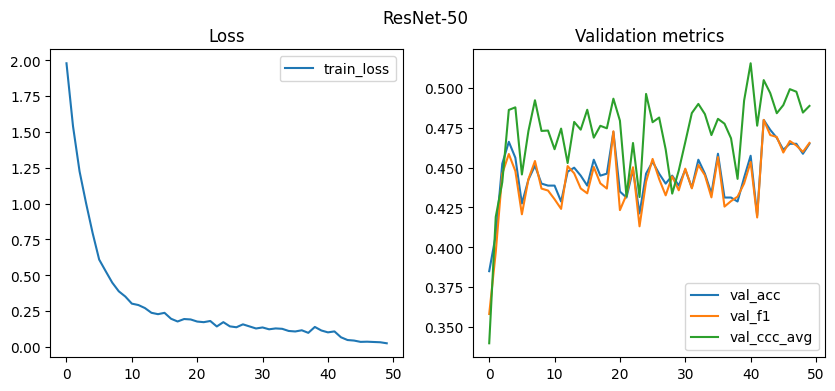

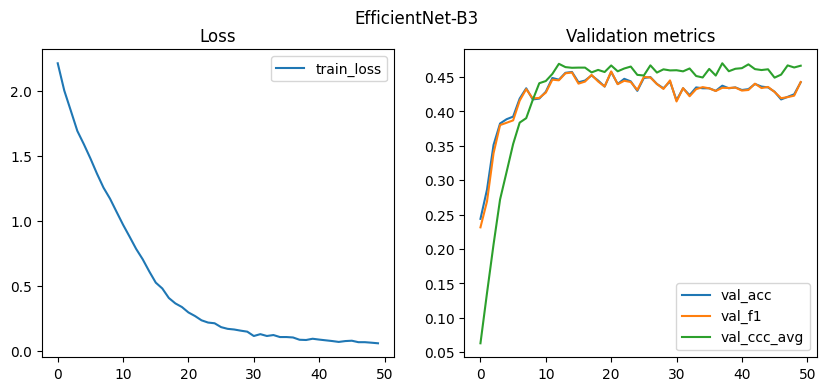

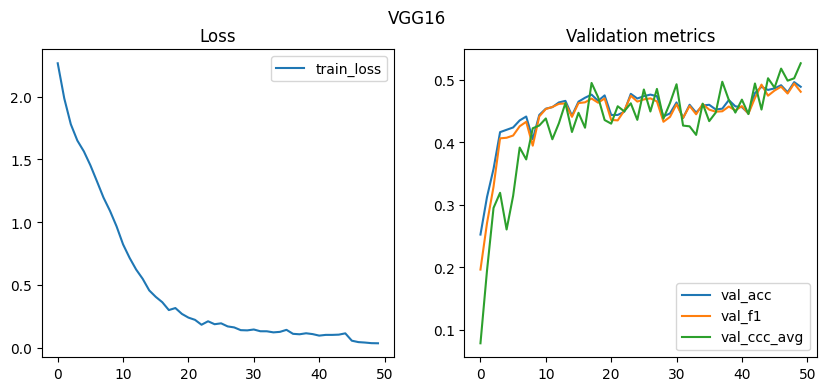

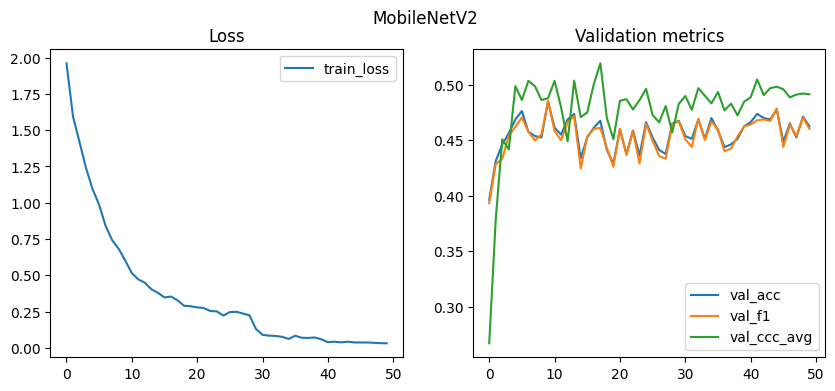

In [14]:
import matplotlib.pyplot as plt

def plot_history(history, title="Training curves"):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train_loss")
    plt.title("Loss"); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["val_acc"], label="val_acc")
    plt.plot(history["val_f1"], label="val_f1")
    plt.plot(history["val_ccc_avg"], label="val_ccc_avg")
    plt.title("Validation metrics"); plt.legend()
    plt.suptitle(title)
    plt.show()

plot_history(resnet_hist, "ResNet-50")
plot_history(effb3_hist, "EfficientNet-B3")
plot_history(vgg_hist, "VGG16")
plot_history(mobilenet_hist, "MobileNetV2")

In [15]:
def krippendorff_alpha_nominal(ratings1, ratings2):
    assert len(ratings1) == len(ratings2)
    if len(ratings1) == 0:
        return float("nan")
    cats = sorted(set(list(ratings1) + list(ratings2)))
    cat_to_idx = {c: i for i, c in enumerate(cats)}
    m = len(cats)
    O = np.zeros((m, m), dtype=float)
    total_pairs = 0.0
    for a, b in zip(ratings1, ratings2):
        ia, ib = cat_to_idx[a], cat_to_idx[b]
        O[ia, ib] += 1.0
        O[ib, ia] += 1.0
        total_pairs += 2.0
    if total_pairs == 0:
        return float("nan")

    Do = (O.sum() - np.trace(O)) / total_pairs
    marg = O.sum(axis=1)
    p = marg / marg.sum()
    De = float((p[:, None] * p[None, :]).sum() - (p ** 2).sum())  # probability of disagreement
    if De == 0:
        return 1.0
    return 1.0 - (Do / De)

def safe_auc_roc(y_true, probs, num_classes):
    try:
        y_bin = label_binarize(y_true, classes=list(range(num_classes)))
        return roc_auc_score(y_bin, np.array(probs), average="macro", multi_class="ovr")
    except Exception:
        return float("nan")

def safe_auc_pr(y_true, probs, num_classes):
    try:
        y_bin = label_binarize(y_true, classes=list(range(num_classes)))
        return average_precision_score(y_bin, np.array(probs), average="macro")
    except Exception:
        return float("nan")

def evaluate_model(model, dataloader, device=DEVICE, num_classes=NUM_CLASSES):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    all_val, all_aro, all_val_pred, all_aro_pred = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Eval"):
            imgs = batch["image"].to(device, non_blocking=True)
            labels = batch["exp"].cpu().numpy()
            valence = batch["valence"].cpu().numpy()
            arousal = batch["arousal"].cpu().numpy()

            logits, reg_out = model(imgs)
            probs = nn.functional.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            reg_np = reg_out.cpu().numpy()

            all_preds.extend(preds.tolist())
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.tolist())
            all_val.extend(valence.tolist()); all_aro.extend(arousal.tolist())
            all_val_pred.extend(reg_np[:, 0].tolist()); all_aro_pred.extend(reg_np[:, 1].tolist())

    # categorical
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    kappa = cohen_kappa_score(all_labels, all_preds)
    kripp = krippendorff_alpha_nominal(all_labels, all_preds)
    auc_roc_ovr = safe_auc_roc(all_labels, all_probs, num_classes)
    auc_pr_macro = safe_auc_pr(all_labels, all_probs, num_classes)

    # continuous
    val_rmse = rmse(all_val, all_val_pred)
    aro_rmse = rmse(all_aro, all_aro_pred)
    val_corr = pearsonr(np.array(all_val), np.array(all_val_pred))[0] if len(all_val) > 1 else float("nan")
    aro_corr = pearsonr(np.array(all_aro), np.array(all_aro_pred))[0] if len(all_aro) > 1 else float("nan")
    val_sagr = sign_agreement(all_val, all_val_pred)
    aro_sagr = sign_agreement(all_aro, all_aro_pred)
    val_ccc = concordance_ccc(all_val, all_val_pred)
    aro_ccc = concordance_ccc(all_aro, all_aro_pred)

    return {
        "acc": acc, "f1_macro": f1_macro, "kappa": kappa, "kripp_alpha": kripp,
        "auc_roc_ovr": auc_roc_ovr, "auc_pr_macro": auc_pr_macro,
        "val_rmse": val_rmse, "aro_rmse": aro_rmse,
        "val_corr": val_corr, "aro_corr": aro_corr,
        "val_sagr": val_sagr, "aro_sagr": aro_sagr,
        "val_ccc": val_ccc, "aro_ccc": aro_ccc,
    }

# <CHANGE> robust checkpoint loading for PyTorch 2.6 (weights_only default) and numpy scalars
def load_best(backbone_name, ckpt_path):
    """
    Loads a saved checkpoint for evaluation, handling:
    - PyTorch 2.6 default weights_only=True causing restricted unpickling
    - Various checkpoint formats: full dict with 'model_state', 'state_dict', or raw state_dict
    - 'module.' prefixes from DDP
    """
    model = MultiTaskModel(backbone_name=backbone_name, pretrained=False).to(DEVICE)

    # Prefer explicit weights_only=False for trusted local checkpoints
    # Fallback to legacy signature if running older torch without the kwarg.
    try:
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    except TypeError:
        # Older torch versions don't support weights_only kwarg
        ckpt = torch.load(ckpt_path, map_location=DEVICE)

    # Extract a proper state_dict from various checkpoint layouts
    if isinstance(ckpt, dict) and "model_state" in ckpt:
        state_dict = ckpt["model_state"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    elif isinstance(ckpt, dict):
        # Might already be a state_dict
        state_dict = ckpt
    else:
        state_dict = ckpt

    # Strip possible 'module.' prefixes (DDP/saved with DataParallel)
    clean_state = {}
    for k, v in state_dict.items():
        nk = k[7:] if k.startswith("module.") else k
        clean_state[nk] = v

    missing, unexpected = model.load_state_dict(clean_state, strict=False)
    if missing:
        print("Missing keys:", missing)
    if unexpected:
        print("Unexpected keys:", unexpected)

    model.eval()
    return model

In [16]:
results = []

# ResNet50
if os.path.exists("./best_resnet50.pth"):
    m = load_best("resnet50", "./best_resnet50.pth")
    r = evaluate_model(m, val_loader)
    r["model"] = "ResNet50"
    r["num_params"] = sum(p.numel() for p in m.parameters())
    results.append(r)

# EfficientNet-B3
if os.path.exists("./best_efficientnet_b3.pth"):
    m = load_best("efficientnet_b3", "./best_efficientnet_b3.pth")
    r = evaluate_model(m, val_loader)
    r["model"] = "EfficientNet-B3"
    r["num_params"] = sum(p.numel() for p in m.parameters())
    results.append(r)

# VGG16
if os.path.exists("./best_vgg16.pth"):
    m = load_best("vgg16", "./best_vgg16.pth")
    r = evaluate_model(m, val_loader)
    r["model"] = "VGG16"
    r["num_params"] = sum(p.numel() for p in m.parameters())
    results.append(r)

# MobileNetV2
if os.path.exists("./best_mobilenet_v2.pth"):
    m = load_best("mobilenet_v2", "./best_mobilenet_v2.pth")
    r = evaluate_model(m, val_loader)
    r["model"] = "MobileNetV2"
    r["num_params"] = sum(p.numel() for p in m.parameters())
    results.append(r)

df = pd.DataFrame(results)
cols = [
    "model", "num_params",
    "acc", "f1_macro", "kappa", "kripp_alpha",
    "auc_roc_ovr", "auc_pr_macro",
    "val_rmse", "aro_rmse",
    "val_corr", "aro_corr",
    "val_sagr", "aro_sagr",
    "val_ccc", "aro_ccc",
]
df = df[[c for c in cols if c in df.columns]]
print(df.to_string(index=False))
df.to_csv("all_models_comparison.csv", index=False)
print("Saved results to all_models_comparison.csv")

Eval: 100%|██████████| 25/25 [00:02<00:00, 10.54it/s]

          model  num_params     acc  f1_macro    kappa  kripp_alpha  auc_roc_ovr  auc_pr_macro  val_rmse  aro_rmse  val_corr  aro_corr  val_sagr  aro_sagr  val_ccc  aro_ccc
       ResNet50    25087306 0.45750  0.453607 0.380000     0.379578     0.810643      0.463151  0.388377  0.336453  0.581566  0.500911   0.76125   0.81875 0.555611 0.475531
EfficientNet-B3    11882290 0.43750  0.434423 0.357143     0.356584     0.796900      0.420861  0.400378  0.338313  0.550278  0.465149   0.74875   0.79500 0.520080 0.420169
          VGG16   137412682 0.48875  0.480811 0.415714     0.414303     0.823693      0.481933  0.384536  0.325216  0.588894  0.535770   0.77375   0.81250 0.560415 0.492281
    MobileNetV2     3213322 0.46750  0.461192 0.391429     0.390202     0.823280      0.463313  0.392032  0.338188  0.572030  0.512582   0.75125   0.80875 0.545825 0.492934
Saved results to all_models_comparison.csv
